In [1]:
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 
import networkx as nx
import warnings
import scanpy as sc
import leidenalg
import igraph as ig
import sklearn
import magic
import scprep
from adjustText import adjust_text
import anndata as ad

warnings.filterwarnings("ignore")

In [2]:
##### CTprops file names correction

In [3]:
CTprops=pd.read_csv('../res_data/revision/deconvolution/PICseq_doublets_CTprops_BP_annotation_noMSCs_Xist.csv', index_col=0)

In [4]:
oldCT=CTprops.columns.copy()
oldCT

Index(['DentriticCells', 'InfiltMac', 'Fibroblast',
       'MonocyteCommitedProgenitor', 'Neutrophiles2', 'Ly6CloInfiltMac',
       'Basophiles', 'TmemCells', 'Neutrophiles1', 'Megakaryocytes',
       'ResidentMac', 'OsteoCAR', 'EC', 'Erythroid', 'OsteoMac', 'BCells'],
      dtype='object')

In [5]:
newCT=['DC', 'InfiltMac', 'Fibro',
       'MonoPro', 'Neut2', 'Ly6ClowMac',
       'Baso', 'TCells', 'Neut1', 'MK',
       'ResMac', 'OsteoCAR', 'EC', 'Ery', 'Spp1+Mac', 'BCells']

In [6]:
CTprops.columns=newCT
CTprops.head()

,DC,InfiltMac,Fibro,MonoPro,Neut2,Ly6ClowMac,Baso,TCells,Neut1,MK,ResMac,OsteoCAR,EC,Ery,Spp1+Mac,BCells
IS3_AAACCCAAGAGTCAGC-1,0.022321,0.009692,0.002134,0.019810,0.027176,0.005223,0.005350,0.006909,0.859264,0.013108,0.004198,0.002142,0.004581,0.008093,0.008558,0.001440
IS3_AAACCCAAGGGCTGAT-1,0.009302,0.013937,0.003087,0.008581,0.013993,0.868811,0.012865,0.014621,0.009612,0.008361,0.005726,0.003589,0.009012,0.008289,0.008231,0.001982
IS3_AAACCCACACGCCAGT-1,0.675809,0.260256,0.001310,0.006162,0.004601,0.005598,0.004135,0.005520,0.009202,0.010234,0.002177,0.001419,0.002356,0.006113,0.004108,0.001000
IS3_AAACCCACACTACCGG-1,0.002942,0.003383,0.001131,0.850736,0.101740,0.002235,0.004787,0.002345,0.007967,0.005849,0.001834,0.001331,0.002962,0.003802,0.006055,0.000903
IS3_AAACCCACAGATCCTA-1,0.030429,0.079342,0.005465,0.013012,0.047528,0.643361,0.025168,0.012989,0.035907,0.018483,0.043229,0.005768,0.010787,0.014002,0.010533,0.003997


In [7]:
CTprops.to_csv('../res_data/revision/deconvolution/PICseq_doublets_CTprops_BP_annotation_noMSCs_Xist_newNames.csv')

In [8]:
######## Database checks

In [9]:
#li.rs.show_resources()

In [10]:
##database checks
#resource = li.rs.select_resource('consensus')
#resource

In [11]:
liana=pd.read_csv('../csv/lianaDB.csv', index_col=0)

In [12]:
nichesphereDB=pd.read_csv('../csv/nichesphereDB_pmid.csv', index_col=0)

In [13]:
nichesphereDB=nichesphereDB.drop_duplicates()
nichesphereDB=nichesphereDB[nichesphereDB.db!='deathbase']
nichesphereDB=nichesphereDB[nichesphereDB.db!='phagocytosis']

In [14]:
## Ligands per category
nichesphereDB.Ligand=nichesphereDB.Ligand.str.lower()
nichesphereDB.category.value_counts()

category
SecretedFactors    265
ECMregulators      204
ECMglycoprots      168
GrowthFactor       130
ECMaffiliated      129
Cytokine            86
Collagens           45
Chemokine           42
Proteoglycans       36
Inhibitory          36
Name: count, dtype: int64

In [15]:
nichesphereDB.db.value_counts()

db
matrisome    847
cytosig      294
Name: count, dtype: int64

In [16]:
### LR pairs per category
for cat in nichesphereDB.category.unique():
    t=pd.Series([i in list(nichesphereDB.Ligand[nichesphereDB.category==cat].str.lower()) for i in list(liana.ligand.str.lower())])
    print(cat, t.value_counts().loc['True':,])

Collagens True    321
Name: count, dtype: int64
ECMaffiliated True    143
Name: count, dtype: int64
ECMglycoprots True    422
Name: count, dtype: int64
ECMregulators True    195
Name: count, dtype: int64
Proteoglycans True    43
Name: count, dtype: int64
SecretedFactors True    1225
Name: count, dtype: int64
Chemokine True    280
Name: count, dtype: int64
Cytokine True    237
Name: count, dtype: int64
GrowthFactor True    1064
Name: count, dtype: int64
Inhibitory True    49
Name: count, dtype: int64


In [17]:
### LR pairs per category
for cat in nichesphereDB.db.unique():
    t=pd.Series([i in list(nichesphereDB.Ligand[nichesphereDB.db==cat].str.lower()) for i in list(liana.ligand.str.lower())])
    print(cat, t.value_counts().loc['True':,])

matrisome True    2349
Name: count, dtype: int64
cytosig True    1589
Name: count, dtype: int64


In [18]:
t=pd.Series([i in list(nichesphereDB.Ligand.str.lower()) for i in list(liana.ligand.str.lower())])
t.value_counts()

True     2846
False    1855
Name: count, dtype: int64

In [19]:
####### Data corrections

In [20]:
adata_singlets=sc.read('../data/PICseq/intermediate_steps/h5ad/PICseq_singlets_noSkMusCells_newNames.h5ad')
adata_doublets=sc.read('../data/PICseq/intermediate_steps/h5ad/PICseq_doublets.h5ad')

In [21]:
adata_singlets.obs.annotation=list(adata_singlets.obs.annotation)
adata_singlets.obs.annotation[adata_singlets.obs.annotation=='OsteoMac']='Spp1+Mac'

In [22]:
adata_doublets.obs=pd.concat([adata_doublets.obs, CTprops], axis=1)

In [23]:
## No Xist
non_Xist_genes_list = [name for name in adata_doublets.var_names if not name.startswith('Xist')]
adata_doublets=adata_doublets[:,non_Xist_genes_list]

non_Xist_genes_list = [name for name in adata_singlets.var_names if not name.startswith('Xist')]
adata_singlets=adata_singlets[:,non_Xist_genes_list]

In [24]:
## UMAP
adata_doublets.obsm['X_umap']=adata_doublets.obsm['X_harmony_umap']
adata_singlets.obsm['X_umap']=adata_singlets.obsm['X_harmony_umap']

In [25]:
##### Doublets annotation
biggestVals=pd.DataFrame([np.sort(CTprops.iloc[i,:])[-1] for i in range(len(CTprops.index))], columns=['Value'])
secondVals=pd.DataFrame([np.sort(CTprops.iloc[i,:])[-2] for i in range(len(CTprops.index))], columns=['Value'])
biggestVals=pd.concat([biggestVals, secondVals], axis=1)
biggestVals.columns=['firstVal', 'secondVal']
biggestVals.index=CTprops.index

In [26]:
CTprops_2CTs=pd.DataFrame(index=CTprops.index, columns=CTprops.columns)
CTprops_2CTs[CTprops>0]=0
for doublet in CTprops.index:
    CTprops_2CTs.loc[doublet][CTprops.loc[doublet]==biggestVals.firstVal[doublet]]=CTprops.loc[doublet][CTprops.loc[doublet]==biggestVals.firstVal[doublet]]
    CTprops_2CTs.loc[doublet][CTprops.loc[doublet]==biggestVals.secondVal[doublet]]=CTprops.loc[doublet][CTprops.loc[doublet]==biggestVals.secondVal[doublet]]
    CTprops_2CTs.loc[doublet]

In [27]:
CTprops_2CTs=(CTprops_2CTs.T/CTprops_2CTs.T.sum()).T
CTprops_2CTs=CTprops_2CTs.astype('float')

In [28]:
CTprops_2CTs.to_csv('../res_data/revision/deconvolution/PICseq_doublets_CTprops_BP_annotation_2CTs_noMSCs_Xist_newNames.csv')

In [29]:
annot=pd.Series([CTprops_2CTs.columns[CTprops_2CTs.loc[x]>0].sort_values()[0]+'-'+CTprops_2CTs.columns[CTprops_2CTs.loc[x]>0].sort_values()[1] for x in CTprops_2CTs.index], index=CTprops_2CTs.index)

In [30]:
## Individual doublet annotation
adata_doublets.obs['annotation']=annot

In [31]:
## Doublet cluster annotation
tmp=CTprops_2CTs.groupby(by=adata_doublets.obs.harmony_inte_clusters).sum()
tmp.head()

,DC,InfiltMac,Fibro,MonoPro,Neut2,Ly6ClowMac,Baso,TCells,Neut1,MK,ResMac,OsteoCAR,EC,Ery,Spp1+Mac,BCells
harmony_inte_clusters,,,,,,,,,,,,,,,,
0,619.614277,2972.178129,3.236898,216.822226,100.569417,2575.438660,4.918509,46.423179,121.921734,64.740220,122.760479,1.432795,7.788074,109.913620,50.853006,6.388775
1,113.701237,40.692480,5.405180,4371.712088,337.818263,26.587029,38.145200,27.193675,573.639020,536.317149,13.341224,2.450647,2.708235,365.706307,47.899137,25.683130
2,92.299922,80.818773,4.892686,454.087309,1797.552502,177.048491,1.542737,12.744846,3494.985272,60.501889,20.411622,2.746140,1.111832,161.348288,38.852830,5.054863
3,63.924503,8.162955,5.834891,248.164335,65.446368,8.172638,11.481326,19.240901,114.258074,705.492270,13.041895,3.472204,5.625628,1429.660119,54.094734,5.927159
4,1605.199178,160.436411,1.750279,390.409600,3.842742,11.314062,0.421260,10.170698,95.952953,177.850488,17.534537,0.175275,0.296881,70.611755,12.197518,1.836365


In [32]:
clust_annot=pd.Series([tmp.loc[x].sort_values(ascending=False).index[0]+'-'+tmp.loc[x].sort_values(ascending=False).index[1] for x in tmp.index], index=tmp.index)
clust_annot

harmony_inte_clusters
0     InfiltMac-Ly6ClowMac
1            MonoPro-Neut1
2              Neut1-Neut2
3                   Ery-MK
4               DC-MonoPro
5            Fibro-MonoPro
6         Spp1+Mac-MonoPro
7        ResMac-Ly6ClowMac
8             Baso-MonoPro
9           Fibro-OsteoCAR
10        OsteoCAR-MonoPro
11           Fibro-MonoPro
12              BCells-Ery
13          TCells-MonoPro
14           MonoPro-Neut1
15                EC-Neut1
dtype: object

In [33]:
adata_doublets.obs['max_pair']=[clust_annot[i] for i in adata_doublets.obs.harmony_inte_clusters]
adata_doublets.obs['max_pair']

IS3_AAACCCAAGAGTCAGC-1             Neut1-Neut2
IS3_AAACCCAAGGGCTGAT-1    InfiltMac-Ly6ClowMac
IS3_AAACCCACACGCCAGT-1              DC-MonoPro
IS3_AAACCCACACTACCGG-1           MonoPro-Neut1
IS3_AAACCCACAGATCCTA-1    InfiltMac-Ly6ClowMac
                                  ...         
IS4_TTTGTTGTCATTTCCA-1             Neut1-Neut2
IS4_TTTGTTGTCCACTGGG-1       ResMac-Ly6ClowMac
IS4_TTTGTTGTCCTCTCTT-1              DC-MonoPro
IS4_TTTGTTGTCCTTATGT-1              DC-MonoPro
IS4_TTTGTTGTCGAAGCAG-1           MonoPro-Neut1
Name: max_pair, Length: 35927, dtype: object

In [34]:
adata_doublets.obs['max_pair']=[adata_doublets.obs['harmony_inte_clusters'][i]+'_'+adata_doublets.obs['max_pair'][i] for i in range(len(adata_doublets.obs['max_pair']))]
adata_doublets.obs['max_pair']

IS3_AAACCCAAGAGTCAGC-1             2_Neut1-Neut2
IS3_AAACCCAAGGGCTGAT-1    0_InfiltMac-Ly6ClowMac
IS3_AAACCCACACGCCAGT-1              4_DC-MonoPro
IS3_AAACCCACACTACCGG-1           1_MonoPro-Neut1
IS3_AAACCCACAGATCCTA-1    0_InfiltMac-Ly6ClowMac
                                   ...          
IS4_TTTGTTGTCATTTCCA-1             2_Neut1-Neut2
IS4_TTTGTTGTCCACTGGG-1       7_ResMac-Ly6ClowMac
IS4_TTTGTTGTCCTCTCTT-1              4_DC-MonoPro
IS4_TTTGTTGTCCTTATGT-1              4_DC-MonoPro
IS4_TTTGTTGTCGAAGCAG-1           1_MonoPro-Neut1
Name: max_pair, Length: 35927, dtype: object

In [35]:
adata_doublets

AnnData object with n_obs × n_vars = 35927 × 20664
    obs: 'nCount_RNA', 'nFeature_RNA', 'name', 'stage', 'percent.mt', 'percent.ribo', 'nCount_decontX', 'nFeature_decontX', 'AmbientRNA', 'decontX_clusters', 'Doublet_classifications', 'percent.exclude', 'S.Score', 'G2M.Score', 'Phase', 'G1.Score', 'CC.Difference', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'seurat_inte_clusters', 'harmony_inte_clusters', 'MCA_annotate', 'external_annotation', 'HCL_annotate', 'DC', 'InfiltMac', 'Fibro', 'MonoPro', 'Neut2', 'Ly6ClowMac', 'Baso', 'TCells', 'Neut1', 'MK', 'ResMac', 'OsteoCAR', 'EC', 'Ery', 'Spp1+Mac', 'BCells', 'annotation', 'max_pair'
    var: 'vst.mean', 'v

In [36]:
adata_singlets

AnnData object with n_obs × n_vars = 27046 × 20788
    obs: 'nCount_RNA', 'nFeature_RNA', 'name', 'stage', 'percent.mt', 'percent.ribo', 'nCount_decontX', 'nFeature_decontX', 'AmbientRNA', 'decontX_clusters', 'Doublet_classifications', 'percent.exclude', 'S.Score', 'G2M.Score', 'Phase', 'G1.Score', 'CC.Difference', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'seurat_inte_clusters', 'harmony_inte_clusters', 'MCA_annotate', 'external_annotation', 'HCL_annotate', 'annotation', 'NABA_COLLAGENS', 'NABA_SECRETED_FACTORS', 'NABA_ECM_GLYCOPROTEINS', 'NABA_CORE_MATRISOME', 'NABA_ECM_REGULATORS', 'NABA_MATRISOME_ASSOCIATED', 'NABA_ECM_AFFILIATED', 'NABA_BASEMENT_MEMB

In [37]:
adata_doublets.write_h5ad('../data/PICseq/final_data/adata_doublets_final.h5ad')

In [38]:
adata_singlets.write_h5ad('../data/PICseq/final_data/adata_singlets_final.h5ad')

In [39]:
########################################### Data imputation

In [40]:
counts=adata_doublets.to_df()

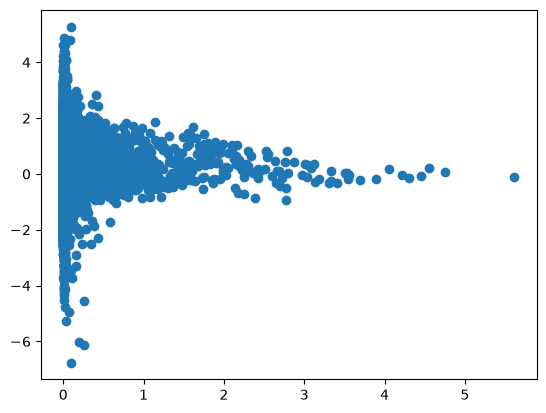

In [41]:
means=counts.mean()
log2FCs=np.log2(counts[adata_doublets.obs.stage=='TPO'].mean()/counts[adata_doublets.obs.stage=='EV'].mean())
plt.scatter(means, log2FCs)

In [42]:
magic_op = magic.MAGIC(solver="approximate")

In [43]:
counts_magic = magic_op.fit_transform(counts, genes='all_genes')

Calculating MAGIC...
  Running MAGIC on 35927 cells and 20664 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 35.47 seconds.
    Calculating KNN search...
    Calculated KNN search in 9.59 seconds.
    Calculating affinities...
    Calculated affinities in 11.74 seconds.
  Calculated graph and diffusion operator in 56.83 seconds.
  Calculating imputation...
  Calculated imputation in 0.20 seconds.
Calculated MAGIC in 62.40 seconds.


In [44]:
magic_op.set_params(t=3)
counts_magic = magic_op.transform(genes='all_genes')
counts_magic.head()

,Rp1,Gm22307,RP23-34E15.1,RP23-34E15.2,Mrpl15,RP23-34E15.5,Lypla1,RP24-426M1.3,Tcea1,RP24-426M1.2,...,Trap1a,Gpr173,Smpx,Map7d2,Asb11,RP23-428E5.2,RP23-428E5.4,Frmpd4,RP24-91H16.1,mt-Tk
IS3_AAACCCAAGAGTCAGC-1,-0.000106,0.002061,0.000477,-0.000184,0.306903,0.022850,0.199808,0.000977,0.303945,0.001877,...,0.000764,-0.000373,-0.001264,0.000180,-0.000062,0.000218,-0.000666,0.000025,0.000194,-0.000445
IS3_AAACCCAAGGGCTGAT-1,0.000941,-0.000218,0.003209,0.000596,0.256587,0.034560,0.167214,-0.000724,0.229516,0.000007,...,0.000249,0.000142,-0.000363,0.000539,-0.000047,0.000089,0.000741,0.000009,-0.000536,-0.000168
IS3_AAACCCACACGCCAGT-1,0.000893,0.000471,0.002202,0.001069,0.411724,0.025234,0.199051,0.001089,0.261991,0.000543,...,-0.000873,-0.000413,-0.000097,-0.000195,-0.000242,0.000235,0.000238,-0.000085,-0.000871,0.000527
IS3_AAACCCACACTACCGG-1,-0.000057,0.002025,0.001235,0.000768,0.511181,0.018047,0.209469,0.002434,0.373746,0.003483,...,0.001116,-0.000111,0.000503,0.000025,0.000664,-0.000053,-0.000647,-0.000413,-0.000237,-0.000784
IS3_AAACCCACAGATCCTA-1,0.000027,-0.000201,0.000576,0.000377,0.184386,0.027804,0.113513,-0.000079,0.180294,-0.000409,...,-0.000056,-0.000542,0.001536,0.000032,0.000231,-0.000028,0.000361,-0.000005,0.000492,0.000211


In [45]:
counts_magic.columns=adata_doublets.var_names
counts_magic.index=adata_doublets.obs_names

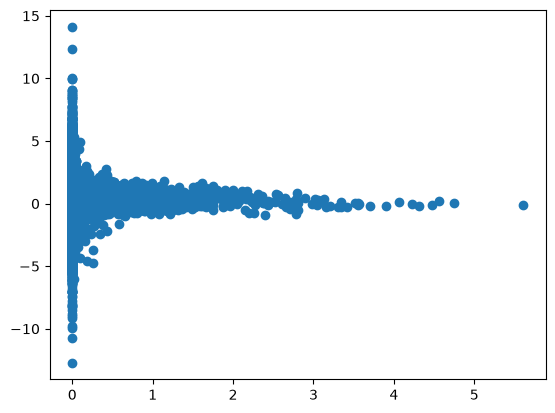

In [46]:
means=counts_magic.mean()
log2FCs=np.log2(counts_magic[adata_doublets.obs.stage=='TPO'].mean()/counts_magic[adata_doublets.obs.stage=='EV'].mean())
plt.scatter(means, log2FCs)

In [47]:
adata_doublets_imp=ad.AnnData(counts_magic)
adata_doublets_imp.obs=adata_doublets.obs
adata_doublets_imp.obsm=adata_doublets.obsm
adata_doublets_imp.uns=adata_doublets.uns
adata_doublets_imp

AnnData object with n_obs × n_vars = 35927 × 20664
    obs: 'nCount_RNA', 'nFeature_RNA', 'name', 'stage', 'percent.mt', 'percent.ribo', 'nCount_decontX', 'nFeature_decontX', 'AmbientRNA', 'decontX_clusters', 'Doublet_classifications', 'percent.exclude', 'S.Score', 'G2M.Score', 'Phase', 'G1.Score', 'CC.Difference', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'seurat_inte_clusters', 'harmony_inte_clusters', 'MCA_annotate', 'external_annotation', 'HCL_annotate', 'DC', 'InfiltMac', 'Fibro', 'MonoPro', 'Neut2', 'Ly6ClowMac', 'Baso', 'TCells', 'Neut1', 'MK', 'ResMac', 'OsteoCAR', 'EC', 'Ery', 'Spp1+Mac', 'BCells', 'annotation', 'max_pair'
    obsm: 'X_bcellcycle

In [48]:
#### Singlets imputation

In [49]:
counts=adata_singlets.to_df()

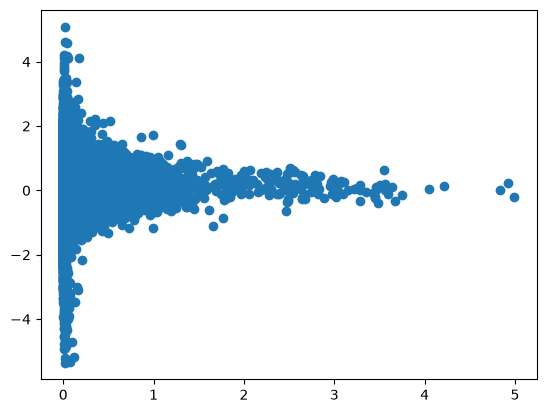

In [50]:
means=counts.mean()
log2FCs=np.log2(counts[adata_singlets.obs.stage=='TPO'].mean()/counts[adata_singlets.obs.stage=='EV'].mean())
plt.scatter(means, log2FCs)

In [51]:
magic_op = magic.MAGIC(solver="approximate")

In [52]:
counts_magic = magic_op.fit_transform(counts, genes='all_genes')

Calculating MAGIC...
  Running MAGIC on 27046 cells and 20788 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 27.40 seconds.
    Calculating KNN search...
    Calculated KNN search in 5.38 seconds.
    Calculating affinities...
    Calculated affinities in 5.95 seconds.
  Calculated graph and diffusion operator in 38.76 seconds.
  Calculating imputation...
  Calculated imputation in 0.10 seconds.
Calculated MAGIC in 42.95 seconds.


In [53]:
magic_op.set_params(t=3)
counts_magic = magic_op.transform(genes='all_genes')
counts_magic.head()

,Rp1,Sox17,RP23-34E15.1,Mrpl15,RP23-34E15.5,Lypla1,RP24-426M1.3,Tcea1,RP24-426M1.2,Rgs20,...,Pcdh11x,RP23-162H9.2,Xkrx,Tmsb15a,Tceal7,Trap1a,RP23-48J18.2,Gpr173,Egfl6,RP23-37L2.2
IS1_AAACCCAAGAAGGGAT-1,0.001834,-0.003130,0.001246,0.702609,0.009812,0.237767,0.002139,0.361727,0.002372,0.000746,...,-0.000059,0.000722,-0.001668,-0.000404,-0.000131,-0.000187,0.000116,0.000140,0.000284,0.000527
IS1_AAACCCAAGAATAGTC-1,0.001393,-0.000160,0.002493,0.367237,0.010260,0.131023,0.001264,0.193501,0.000609,-0.000784,...,0.000340,-0.000136,-0.000408,-0.000100,-0.000072,-0.000230,0.000150,-0.000071,0.000259,-0.000491
IS1_AAACCCAAGTTCCAGT-1,0.001219,0.082848,-0.002007,0.179305,0.010290,0.156816,0.001901,0.380250,-0.001003,0.009783,...,-0.001017,0.000390,-0.002536,-0.002440,-0.000985,0.000631,0.000338,0.001874,0.012255,-0.000557
IS1_AAACCCACAGAACATA-1,0.001262,-0.002951,0.001654,0.924807,0.007938,0.193634,0.002054,0.423898,0.004423,-0.000288,...,-0.000791,0.000120,-0.000348,0.000820,0.000813,-0.000745,0.000402,0.000972,0.000508,-0.000279
IS1_AAACCCACATAATCCG-1,0.000864,-0.004407,0.003364,0.650287,0.014208,0.224100,0.001678,0.363487,0.004909,-0.000285,...,-0.000677,0.000272,0.002986,0.000498,0.000272,0.000014,-0.000198,-0.000477,0.000709,0.000727


In [54]:
counts_magic.columns=adata_singlets.var_names
counts_magic.index=adata_singlets.obs_names

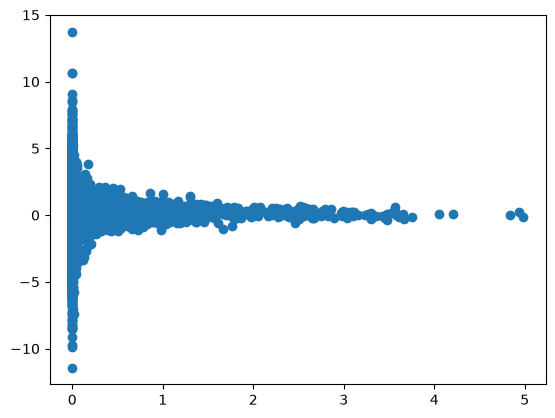

In [55]:
means=counts_magic.mean()
log2FCs=np.log2(counts_magic[adata_singlets.obs.stage=='TPO'].mean()/counts_magic[adata_singlets.obs.stage=='EV'].mean())
plt.scatter(means, log2FCs)

In [56]:
adata_singlets_imp=ad.AnnData(counts_magic)
adata_singlets_imp.obs=adata_singlets.obs
adata_singlets_imp.obsm=adata_singlets.obsm
adata_singlets_imp.uns=adata_singlets.uns
adata_singlets_imp

AnnData object with n_obs × n_vars = 27046 × 20788
    obs: 'nCount_RNA', 'nFeature_RNA', 'name', 'stage', 'percent.mt', 'percent.ribo', 'nCount_decontX', 'nFeature_decontX', 'AmbientRNA', 'decontX_clusters', 'Doublet_classifications', 'percent.exclude', 'S.Score', 'G2M.Score', 'Phase', 'G1.Score', 'CC.Difference', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'seurat_inte_clusters', 'harmony_inte_clusters', 'MCA_annotate', 'external_annotation', 'HCL_annotate', 'annotation', 'NABA_COLLAGENS', 'NABA_SECRETED_FACTORS', 'NABA_ECM_GLYCOPROTEINS', 'NABA_CORE_MATRISOME', 'NABA_ECM_REGULATORS', 'NABA_MATRISOME_ASSOCIATED', 'NABA_ECM_AFFILIATED', 'NABA_BASEMENT_MEMB

In [57]:
adata_doublets_imp

AnnData object with n_obs × n_vars = 35927 × 20664
    obs: 'nCount_RNA', 'nFeature_RNA', 'name', 'stage', 'percent.mt', 'percent.ribo', 'nCount_decontX', 'nFeature_decontX', 'AmbientRNA', 'decontX_clusters', 'Doublet_classifications', 'percent.exclude', 'S.Score', 'G2M.Score', 'Phase', 'G1.Score', 'CC.Difference', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'seurat_inte_clusters', 'harmony_inte_clusters', 'MCA_annotate', 'external_annotation', 'HCL_annotate', 'DC', 'InfiltMac', 'Fibro', 'MonoPro', 'Neut2', 'Ly6ClowMac', 'Baso', 'TCells', 'Neut1', 'MK', 'ResMac', 'OsteoCAR', 'EC', 'Ery', 'Spp1+Mac', 'BCells', 'annotation', 'max_pair'
    obsm: 'X_bcellcycle

In [58]:
adata_singlets

AnnData object with n_obs × n_vars = 27046 × 20788
    obs: 'nCount_RNA', 'nFeature_RNA', 'name', 'stage', 'percent.mt', 'percent.ribo', 'nCount_decontX', 'nFeature_decontX', 'AmbientRNA', 'decontX_clusters', 'Doublet_classifications', 'percent.exclude', 'S.Score', 'G2M.Score', 'Phase', 'G1.Score', 'CC.Difference', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'seurat_inte_clusters', 'harmony_inte_clusters', 'MCA_annotate', 'external_annotation', 'HCL_annotate', 'annotation', 'NABA_COLLAGENS', 'NABA_SECRETED_FACTORS', 'NABA_ECM_GLYCOPROTEINS', 'NABA_CORE_MATRISOME', 'NABA_ECM_REGULATORS', 'NABA_MATRISOME_ASSOCIATED', 'NABA_ECM_AFFILIATED', 'NABA_BASEMENT_MEMB

In [59]:
adata_doublets

AnnData object with n_obs × n_vars = 35927 × 20664
    obs: 'nCount_RNA', 'nFeature_RNA', 'name', 'stage', 'percent.mt', 'percent.ribo', 'nCount_decontX', 'nFeature_decontX', 'AmbientRNA', 'decontX_clusters', 'Doublet_classifications', 'percent.exclude', 'S.Score', 'G2M.Score', 'Phase', 'G1.Score', 'CC.Difference', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'seurat_inte_clusters', 'harmony_inte_clusters', 'MCA_annotate', 'external_annotation', 'HCL_annotate', 'DC', 'InfiltMac', 'Fibro', 'MonoPro', 'Neut2', 'Ly6ClowMac', 'Baso', 'TCells', 'Neut1', 'MK', 'ResMac', 'OsteoCAR', 'EC', 'Ery', 'Spp1+Mac', 'BCells', 'annotation', 'max_pair'
    var: 'vst.mean', 'v

In [60]:
adata_doublets_imp.obs=adata_doublets_imp.obs[['nCount_RNA', 'nFeature_RNA', 'name', 'stage', 'percent.mt', 'percent.ribo', 'nCount_decontX', 'nFeature_decontX', 'AmbientRNA', 
                                       'decontX_clusters', 'Doublet_classifications', 'percent.exclude', 'S.Score', 'G2M.Score', 'Phase', 'G1.Score', 'CC.Difference', 
                                       'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 
                                       'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 
                                       'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'seurat_inte_clusters', 
                                       'harmony_inte_clusters', 'annotation', 'max_pair']]

In [61]:
adata_singlets_imp.obs=adata_singlets_imp.obs[['nCount_RNA', 'nFeature_RNA', 'name', 'stage', 'percent.mt', 'percent.ribo', 'nCount_decontX', 'nFeature_decontX', 'AmbientRNA', 
                                       'decontX_clusters', 'Doublet_classifications', 'percent.exclude', 'S.Score', 'G2M.Score', 'Phase', 'G1.Score', 'CC.Difference', 
                                       'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 
                                       'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 
                                       'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'seurat_inte_clusters', 
                                       'harmony_inte_clusters', 'annotation']]

In [62]:
## imputation changes slightly between runs , so we won't save new objects anymore

In [63]:
#adata_doublets_imp.write_h5ad('../data/PICseq/final_data/adata_doublets_final_imp.h5ad')

In [64]:
#adata_singlets_imp.write_h5ad('../data/PICseq/final_data/adata_singlets_final_imp.h5ad')